#### Abstract

This notebook addresses missing value handling for our flight traces time series data. Missing values are cleansed on a per-flight-id basis using linear interpolation, forward and backward fill ensuring that interpolation boundaries remain strictly within individual flight trajectories.

 This grouping strategy prevents cross-flight information leakage, as no values are inferred from neighboring flights or from the test set. The choice to perform this step before splitting is justified by the sample-level independence of each flight: since interpolation operates solely within a single flight's temporal window, no statistical information crosses the train-test boundary. The resulting dataset is free of missing values and ready for feature extraction and subsequent model training.

In [1]:

from paths import *
import pandas as pd
import duckdb

from src.common.plots import *
from src.common.data_integrity import *

In [2]:
#CRASH_PATH  = PARQUET_TRACES_CRASH / "traces_00.pq"
NORMAL_PATH = PARQUET_TRACES_NO_CRASH / "*.pq"

#### Schema Analysis

In [3]:
con = duckdb.connect()
print(con.sql(f"DESCRIBE SELECT  * FROM parquet_scan('{NORMAL_PATH}')").df())

   column_name                                        column_type null   key  \
0      dbFlags                                             BIGINT  YES  None   
1         desc                                            VARCHAR  YES  None   
2         icao                                            VARCHAR  YES  None   
3            r                                            VARCHAR  YES  None   
4  reg_details  STRUCT(description VARCHAR, iso2 VARCHAR, iso3...  YES  None   
5            t                                            VARCHAR  YES  None   
6    timestamp                                            VARCHAR  YES  None   
7        trace  STRUCT(aircraft STRUCT(alert BIGINT, alt_geom ...  YES  None   
8        ownOp                                            VARCHAR  YES  None   
9         year                                            VARCHAR  YES  None   

  default extra  
0    None  None  
1    None  None  
2    None  None  
3    None  None  
4    None  None  
5    None  

The schema has 10 columns total. The columns are identical to the columsn of the accident-dataset, execept for the version column, which is missing here. This column can be ignored.

In [4]:
con.execute(f"SELECT * FROM read_parquet('{NORMAL_PATH}') LIMIT 5").df()

,dbFlags,desc,icao,r,reg_details,t,timestamp,trace,ownOp,year
0,0,AIRBUS A-320NEO,010205,SU-GFK,"{'description': 'general', 'iso2': 'EG', 'iso3...",A20N,2023-08-30 00:00:00+00:00,"{'aircraft': {'alert': None, 'alt_geom': None,...",None,None
1,0,AIRBUS A-320NEO,010205,SU-GFK,"{'description': 'general', 'iso2': 'EG', 'iso3...",A20N,2023-08-30 00:00:00+00:00,"{'aircraft': {'alert': None, 'alt_geom': None,...",None,None
2,0,AIRBUS A-320NEO,010205,SU-GFK,"{'description': 'general', 'iso2': 'EG', 'iso3...",A20N,2023-08-30 00:00:00+00:00,"{'aircraft': {'alert': 0, 'alt_geom': 40525.0,...",None,None
3,0,AIRBUS A-320NEO,010205,SU-GFK,"{'description': 'general', 'iso2': 'EG', 'iso3...",A20N,2023-08-30 00:00:00+00:00,"{'aircraft': {'alert': None, 'alt_geom': None,...",None,None
4,0,AIRBUS A-320NEO,010205,SU-GFK,"{'description': 'general', 'iso2': 'EG', 'iso3...",A20N,2023-08-30 00:00:00+00:00,"{'aircraft': {'alert': None, 'alt_geom': None,...",None,None


In [5]:
con.execute(f"DESCRIBE SELECT * FROM read_parquet('{NORMAL_PATH}')").df()

,column_name,column_type,null,key,default,extra
0,dbFlags,BIGINT,YES,None,None,None
1,desc,VARCHAR,YES,None,None,None
2,icao,VARCHAR,YES,None,None,None
3,r,VARCHAR,YES,None,None,None
4,reg_details,"STRUCT(description VARCHAR, iso2 VARCHAR, iso3...",YES,None,None,None
5,t,VARCHAR,YES,None,None,None
6,timestamp,VARCHAR,YES,None,None,None
7,trace,"STRUCT(aircraft STRUCT(alert BIGINT, alt_geom ...",YES,None,None,None
8,ownOp,VARCHAR,YES,None,None,None
9,year,VARCHAR,YES,None,None,None


In [6]:
print(con.execute(f"SELECT COUNT(*) FROM read_parquet('{NORMAL_PATH}')").df())

   count_star()
0      62394697


In [7]:
con.execute(f"SELECT typeof(trace) FROM read_parquet('{NORMAL_PATH}') LIMIT 1").df()

,typeof(trace)
0,"STRUCT(aircraft STRUCT(alert BIGINT, alt_geom ..."


Dataset structure:

Each row represents a single trace point (snapshot every few seconds) of a flight.
A unique flight is identified by 'icao' + 'timestamp' (date), with the exact position/speed/altitude data nested inside the 'trace' column. There are also other identifier like registration.

We have around 62 million traces, spanning from 2023-2026, let's find out how many airplanes we have in this random dataset.

In [8]:
con.execute(f"""
    SELECT 
        COUNT(DISTINCT icao) AS unique_aircraft,
    FROM read_parquet('{NORMAL_PATH}')
""").df()

,unique_aircraft
0,46399


We have ~ 46000 aircrafts (identified by ICAO => rough estimate)

#### Trace Struct-Field Analysis

In [9]:
con.execute(f"SELECT trace.* FROM read_parquet('{NORMAL_PATH}') LIMIT 5").df()

,aircraft,altitude,flags,geometric_altitude,geometric_vertical_rate,ground_speed,h3_5,indicated_airspeed,lat,lon,roll_angle,source,timestamp,track_degrees,vertical_rate
0,"{'alert': None, 'alt_geom': None, 'baro_rate':...",38025.0,1,40525.0,32.0,420.2,853e6873fffffff,248,28.987564,35.184931,0.0,adsb_icao,2023-08-30 03:23:50.550000+00:00,279.0,0.0
1,"{'alert': None, 'alt_geom': None, 'baro_rate':...",38025.0,0,40525.0,32.0,420.2,853e6873fffffff,247,28.989847,35.168637,-0.2,adsb_icao,2023-08-30 03:24:01.180000+00:00,279.0,0.0
2,"{'alert': 0, 'alt_geom': 40525.0, 'baro_rate':...",38025.0,1,40525.0,0.0,420.2,853e6873fffffff,247,28.992462,35.150176,-0.2,adsb_icao,2023-08-30 03:24:28.810000+00:00,279.0,64.0
3,"{'alert': None, 'alt_geom': None, 'baro_rate':...",38000.0,1,40500.0,NaN,420.2,853e6847fffffff,<NA>,29.008049,35.039493,NaN,adsb_icao,2023-08-30 03:24:59.180000+00:00,279.0,64.0
4,"{'alert': None, 'alt_geom': None, 'baro_rate':...",38025.0,0,40525.0,NaN,NaN,853e6847fffffff,<NA>,29.011587,35.014128,NaN,adsb_icao,2023-08-30 03:25:08.750000+00:00,NaN,NaN


In [10]:
con.execute(f"SUMMARIZE SELECT trace.* FROM read_parquet('{NORMAL_PATH}')").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,aircraft,"STRUCT(alert BIGINT, alt_geom DOUBLE, baro_rat...","{'alert': 0, 'alt_geom': -3350.0, 'baro_rate':...","{'alert': NULL, 'alt_geom': NULL, 'baro_rate':...",16577418,NaN,NaN,NaN,NaN,NaN,62394697,0.00
1,altitude,DOUBLE,-1000.0,124100.0,2081,17150.632427218192,14038.749803166187,4003.1967190418336,11973.722666735533,32347.877253395338,62394697,6.50
2,flags,BIGINT,0,15,17,0.6198535430022202,1.435463404656621,0,0,0,62394697,0.00
3,geometric_altitude,DOUBLE,-4150.0,123625.0,2426,17460.521442232588,14385.818608940173,4025.2086267483537,12067.094895733759,32956.736724282455,62394697,6.76
4,geometric_vertical_rate,DOUBLE,-32640.0,32640.0,1270,125.47451446338127,1393.0949894151233,-604.0905634026394,0.0,596.8476699698892,62394697,50.13
5,ground_speed,DOUBLE,0.0,5781.3,8100,281.6480893579346,154.69521304661004,141.71208327136267,285.09334182684813,422.40388827940285,62394697,0.97
6,h3_5,VARCHAR,8500eb6ffffffff,85e1561bfffffff,150983,NaN,NaN,NaN,NaN,NaN,62394697,0.00
7,indicated_airspeed,BIGINT,0,3300,753,248.23861883182198,47.05863733521858,232,254,277,62394697,67.30
8,lat,DOUBLE,-63.717724,89.973495,4352500,34.976060320343834,18.984936594048616,32.98557303268975,38.848549212145464,44.20889471667754,62394697,0.00
9,lon,DOUBLE,-179.997195,179.995067,19344634,-46.468716767489795,74.46387004780983,-97.4765338064866,-80.21260272799908,4.834788617030641,62394697,0.00


The dataset contains ~62 million ADS-B trace points from randomly selected flights between August 2023 and December 2025, with:

- Spatial coverage across latitudes from -63.7° to 89.8° and the full longitude range. It covers nearly the entire globe.
- Altitudes spanning from -1,000 to 124,300 ft (avg ~16,700 ft). The maximum value is clearly unrealistic for standard commercial operations (typical cruise ceilings ~45,000 ft) and likely represents outliers or data errors rather than actual flight levels.
- Ground speeds from 0 to 5,781 knots (avg ~275 knots). The average matches typical commercial cruise speeds, max-value is an outlier (typical commercial ~500–600 knots).
- Track headings covering the full 0–360° range — normal
- Vertical rates from -130,520 to +39,408 ft/min (avg ~127 ft/min). The Average is close to zero as expected, extreme min/max values are outliers (realistic range ±6,000 ft/min)
- Roll angles between -39.9° and +39.9°. The normal, within typical flight envelope
- 5 different source types (from `adsb_icao` to `tisb_icao`). Very normal.
- H3 hexagonal spatial index (resolution 5) with ~173k unique cells covered (good global spread)


Flags field defintion from ADS-Exchange (https://www.adsbexchange.com/version-2-api-wip/)

flags are a bitfield: (use bitwise and to extract data) 
- (flags & 1 > 0): position is stale (no position received for 20 seconds before this one)
- (flags & 2 > 0): start of a new leg (tries to detect a separation point between landing and takeoff that separates flights)
- (flags & 4 > 0): vertical rate is geometric and not barometric
- (flags & 8 > 0): altitude is geometric and not barometric ADS-B Exchange

#### Duplicate Check

In [11]:
con.sql(f"""
SELECT
    COUNT(*)                                                    AS total_rows,
    COUNT(*) - COUNT(DISTINCT (icao, trace.timestamp))          AS duplicate_rows,
    (COUNT(*) - COUNT(DISTINCT (icao, trace.timestamp))) * 100.0 / COUNT(*) AS pct_duplicates
FROM parquet_scan('{NORMAL_PATH}')
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,duplicate_rows,pct_duplicates
0,62394697,13370,0.021428


Sources Duplicate combinations

In [12]:
con.sql(f"""
WITH dups AS (
    SELECT icao, trace.timestamp AS ts
    FROM parquet_scan('{NORMAL_PATH}')
    GROUP BY icao, trace.timestamp
    HAVING COUNT(*) > 1
)
SELECT p.trace.source, COUNT(*) AS n
FROM parquet_scan('{NORMAL_PATH}') p
JOIN dups ON p.icao = dups.icao AND p.trace.timestamp = dups.ts
GROUP BY p.trace.source
ORDER BY n DESC
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,source,n
0,adsr_icao,15673
1,adsb_icao,7317
2,tisb_icao,2268
3,mlat,1179
4,adsb_icao_nt,188


We checked for duplicate rows based on `icao` + `trace.timestamp`. Only **0.02%** were flagged as duplicates. Breaking down by source, most originate from `adsr_icao` (15,673), followed by `adsb_icao` (7,317), `tisb_icao` (2,268), `mlat` (1,179), and `adsb_icao_nt` (188).

These are **near-duplicates**, multiple receivers reporting the same signal with micro-level positional differences. Given their negligible share and the explainable cause, we will remove these duplicate rows later on. 

In [13]:
OUTPUT_PATH = PROCESSED_DIR / "normal_traces.parquet"

We already know from our accident Notebook that we only need these columns, thus we will export them into a new parquet file, which we will use from now on

In [14]:
con.execute("SET TimeZone='UTC';")
con.sql(f"""
COPY (
    SELECT 
        icao,
        t                        AS type,
        dbFlags,
        CAST(trace.timestamp AS TIMESTAMPTZ) AS timestamp,
        trace.lat                AS lat,
        trace.lon                AS lon,
        trace.altitude           AS altitude,
        trace.geometric_altitude AS altitude_geom,
        trace.ground_speed       AS ground_speed,
        trace.track_degrees      AS track_degrees,
        trace.vertical_rate      AS vertical_rate,
        trace.flags              AS flags,
        trace.source             AS source,
        trace.h3_5               AS h3_5
    FROM parquet_scan('{NORMAL_PATH}')
) TO '{OUTPUT_PATH}' (FORMAT PARQUET)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [15]:
con.execute(f"SELECT * FROM read_parquet('{OUTPUT_PATH}') LIMIT 5").df()

,icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5
0,010205,A20N,0,2023-08-30 03:23:50.550000+00:00,28.987564,35.184931,38025.0,40525.0,420.2,279.0,0.0,1,adsb_icao,853e6873fffffff
1,010205,A20N,0,2023-08-30 03:24:01.180000+00:00,28.989847,35.168637,38025.0,40525.0,420.2,279.0,0.0,0,adsb_icao,853e6873fffffff
2,010205,A20N,0,2023-08-30 03:24:28.810000+00:00,28.992462,35.150176,38025.0,40525.0,420.2,279.0,64.0,1,adsb_icao,853e6873fffffff
3,010205,A20N,0,2023-08-30 03:24:59.180000+00:00,29.008049,35.039493,38000.0,40500.0,420.2,279.0,64.0,1,adsb_icao,853e6847fffffff
4,010205,A20N,0,2023-08-30 03:25:08.750000+00:00,29.011587,35.014128,38025.0,40525.0,NaN,NaN,NaN,0,adsb_icao,853e6847fffffff


In [16]:
NON_DUPLICATE_PATH = PROCESSED_DIR / "non_duplicate_traces.parquet"

In [17]:
con.sql(f"""
COPY (
    SELECT *
    FROM parquet_scan('{OUTPUT_PATH}') 
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY icao, timestamp
        ORDER BY source
    ) = 1
) TO '{NON_DUPLICATE_PATH}' (FORMAT PARQUET)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [18]:
import polars as pl

In [19]:
print(pl.scan_parquet(OUTPUT_PATH).collect().shape)
print(pl.scan_parquet(NON_DUPLICATE_PATH).collect().shape)

(62394697, 14)
(62381327, 14)


##### Flight Identification

**Goal:** Assign a unique `flight_id` per continuous flight trajectory per ICAO.
We split flights using a 30-min time gap threshold, but only when the aircraft 
was near the ground (altitude < 500ft) at the split point, ensuring mid-cruise 
ADS-B dropouts are not mistakenly treated as separate flights.

**Note:** 500ft (~150m) was chosen as the altitude cutoff as it corresponds to 
final approach phase (https://skybrary.aero/tutorials/descent-approach-and-landing), where no commercial jet is in cruise or climb. 

In [20]:
df = pl.read_parquet(NON_DUPLICATE_PATH)

In [21]:
df = df.sort(['icao', 'timestamp'])

In [22]:
print(f"Unique aircraft/ICAOs: {df['icao'].n_unique()}")

Unique aircraft/ICAOs: 46399


In [23]:
(
    df
    .select(['icao', pl.col('timestamp').dt.date().alias('date')])
    .unique()
    .group_by('icao')
    .agg(pl.col('date').n_unique().alias('n_days'))
    .filter(pl.col('n_days') > 1)
    .sort('n_days', descending=True)
)

icao,n_days
str,u32
"""71c354""",4
"""4aca15""",4
"""0a80a3""",4
"""ac5436""",4
"""885315""",4
…,…
"""4d24c4""",2
"""7c26d4""",2
"""a87cf9""",2


Around 12 thousand icaos span multiple days (max 4 days)

In [24]:
nan_alt = df.filter(pl.col('altitude').is_null())
print(nan_alt['ground_speed'].describe())

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 3.891648e6 │
│ null_count ┆ 158800.0   │
│ mean       ┆ 16.509608  │
│ std        ┆ 22.330829  │
│ min        ┆ 0.0        │
│ 25%        ┆ 4.8        │
│ 50%        ┆ 11.2       │
│ 75%        ┆ 18.5       │
│ max        ┆ 5781.3     │
└────────────┴────────────┘


When altitude is NaN, the median ground_speed is only 11.2, way too slow for a flying aircraft. So NaN altitude mostly means the plane is on the ground (taxiing, parked) → fill_null(True) is the correct assumption for our function below, where we are seperating the flights correctly. 

In [25]:
df2 = df.with_columns(
    time_gap=(pl.col('timestamp').diff().over('icao') > pl.duration(minutes=20)),
    long_gap=(pl.col('timestamp').diff().over('icao') > pl.duration(hours=20)),  # hard cap
    near_ground=(
        (pl.col('altitude').abs() < 3000) |  
        (pl.col('ground_speed') < 50)
    ).fill_null(True),
    is_first=pl.col('timestamp').diff().over('icao').is_null()
).with_columns(
    new_flight=(pl.col('time_gap') & pl.col('near_ground')) | pl.col('long_gap') | pl.col('is_first')
).with_columns(
    flight_id_num=pl.col('new_flight').cast(pl.Int32).cum_sum().over('icao')
).with_columns(
    flight_id=pl.col('icao') + '_' + pl.col('flight_id_num').cast(pl.Utf8)
).drop(['time_gap', 'long_gap', 'near_ground', 'is_first', 'new_flight', 'flight_id_num'])

# Check
print(f"Nulls in flight_id: {df2['flight_id'].is_null().sum()}")
print(f"Total ICAOs: {df2['icao'].n_unique()}")
print(f"Total flights: {df2['flight_id'].n_unique()}")

Nulls in flight_id: 0
Total ICAOs: 46399
Total flights: 141455


In [26]:
from datetime import timedelta

In [27]:
gaps2 = df2.group_by('flight_id').agg(
    pl.col('timestamp').diff().alias('gap')
).explode('gap')['gap']

print(gaps2.describe())
print(f"\nGaps > 15min: {(gaps2 > timedelta(minutes=15)).sum()}")
print(f"Gaps > 30min: {(gaps2 > timedelta(minutes=30)).sum()}")
print(f"Gaps > 1h:    {(gaps2 > timedelta(hours=1)).sum()}")
print(f"Gaps > 6h:    {(gaps2 > timedelta(hours=6)).sum()}")

shape: (8, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ value           │
│ ---        ┆ ---             │
│ str        ┆ str             │
╞════════════╪═════════════════╡
│ count      ┆ 62239872        │
│ null_count ┆ 141455          │
│ mean       ┆ 0:00:20.471340  │
│ min        ┆ 0:00:00.010000  │
│ 25%        ┆ 0:00:03.060000  │
│ 50%        ┆ 0:00:07.260000  │
│ 75%        ┆ 0:00:17.550000  │
│ max        ┆ 19:58:28.470000 │
└────────────┴─────────────────┘

Gaps > 15min: 71587
Gaps > 30min: 54321
Gaps > 1h:    43643
Gaps > 6h:    6987


In [28]:
durations = df2.group_by('flight_id').agg(
    (pl.col('timestamp').max() - pl.col('timestamp').min()).alias('duration')
)['duration']

print(durations.describe())
print(f"\nDuration > 1h:   {(durations > timedelta(hours=1)).sum()}")
print(f"Duration > 6h:   {(durations > timedelta(hours=6)).sum()}")
print(f"Duration > 12h:  {(durations > timedelta(hours=12)).sum()}")
print(f"Duration > 18h:  {(durations > timedelta(hours=18)).sum()}")
print(f"Duration > 24h:  {(durations > timedelta(hours=24)).sum()}")

shape: (8, 2)
┌────────────┬────────────────────────┐
│ statistic  ┆ value                  │
│ ---        ┆ ---                    │
│ str        ┆ str                    │
╞════════════╪════════════════════════╡
│ count      ┆ 141455                 │
│ null_count ┆ 0                      │
│ mean       ┆ 2:30:07.342141         │
│ min        ┆ 0:00:00                │
│ 25%        ┆ 0:29:46.310000         │
│ 50%        ┆ 1:13:18.050000         │
│ 75%        ┆ 2:45:47.400000         │
│ max        ┆ 1 day, 23:59:48.790000 │
└────────────┴────────────────────────┘

Duration > 1h:   80239
Duration > 6h:   15316
Duration > 12h:  4884
Duration > 18h:  1596
Duration > 24h:  237


We will delete all flights, which have no duration

In [29]:
df2 = df2.filter(pl.col('flight_id').is_in(
    df2.group_by('flight_id').agg(
        duration_h=(pl.col('timestamp').max() - pl.col('timestamp').min()).dt.total_seconds() / 3600
    ).filter(pl.col('duration_h') > 0)['flight_id'].to_list()
))

In [30]:
point_density = df2.lazy().group_by('flight_id').agg(
    n_points=pl.len(),
    duration_h=(pl.col('timestamp').max() - pl.col('timestamp').min()).dt.total_seconds() / 3600
).with_columns(
    points_per_hour=pl.col('n_points') / pl.col('duration_h')
).collect()['points_per_hour']

print(point_density.describe())
print(f"\nDensity < 30:  {(point_density < 30).sum()}")
print(f"Density < 60:  {(point_density < 60).sum()}")
print(f"Density < 100: {(point_density < 100).sum()}")
print(f"Density < 300: {(point_density < 300).sum()}")

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 140707.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ 353.052813 │
│ std        ┆ 355.684469 │
│ min        ┆ 0.214439   │
│ 25%        ┆ 178.314256 │
│ 50%        ┆ 305.405405 │
│ 75%        ┆ 444.827586 │
│ max        ┆ 10800.0    │
└────────────┴────────────┘

Density < 30:  4659
Density < 60:  11186
Density < 100: 19467
Density < 300: 68637


Related to the means of these two summaries, we will delete all flights with the following cases:

- Duration < 20 minutes
- Duration > 20 hours
- Max internal gap > 2 hours
- Points per hour < 60

In [31]:
from datetime import timedelta

valid_flight_ids = (
    df2.lazy()
    .group_by('flight_id')
    .agg(
        duration=pl.col('timestamp').max() - pl.col('timestamp').min(),
        n_points=pl.len(),
        max_gap=pl.col('timestamp').diff().max()
    )
    .filter(
        (pl.col('duration') >= timedelta(minutes=20)) &
        (pl.col('duration') <= timedelta(hours=20)) 
        &(pl.col('n_points') / (pl.col('duration').dt.total_seconds() / 3600) >= 60) 
        & (pl.col('max_gap') <= timedelta(hours=2))
    )
    .select('flight_id')
    .collect()
)

df2 = df2.filter(pl.col('flight_id').is_in(valid_flight_ids['flight_id'].to_list()))
print(f"Flights after filter: {df2['flight_id'].n_unique()}")

Flights after filter: 93935


In [32]:
gap_df = (
    df2.lazy()
    .group_by('flight_id')
    .agg(
        max_gap=pl.col('timestamp').diff().max(),
        n_points=pl.len(),
        icao=pl.col('icao').first(),
        t_start=pl.col('timestamp').min(),
        t_end=pl.col('timestamp').max(),
        duration=pl.col('timestamp').max() - pl.col('timestamp').min()
    )
    .sort('max_gap', descending=True)
    .collect()
)

In [33]:
top_icaos = gap_df["flight_id"].to_list()

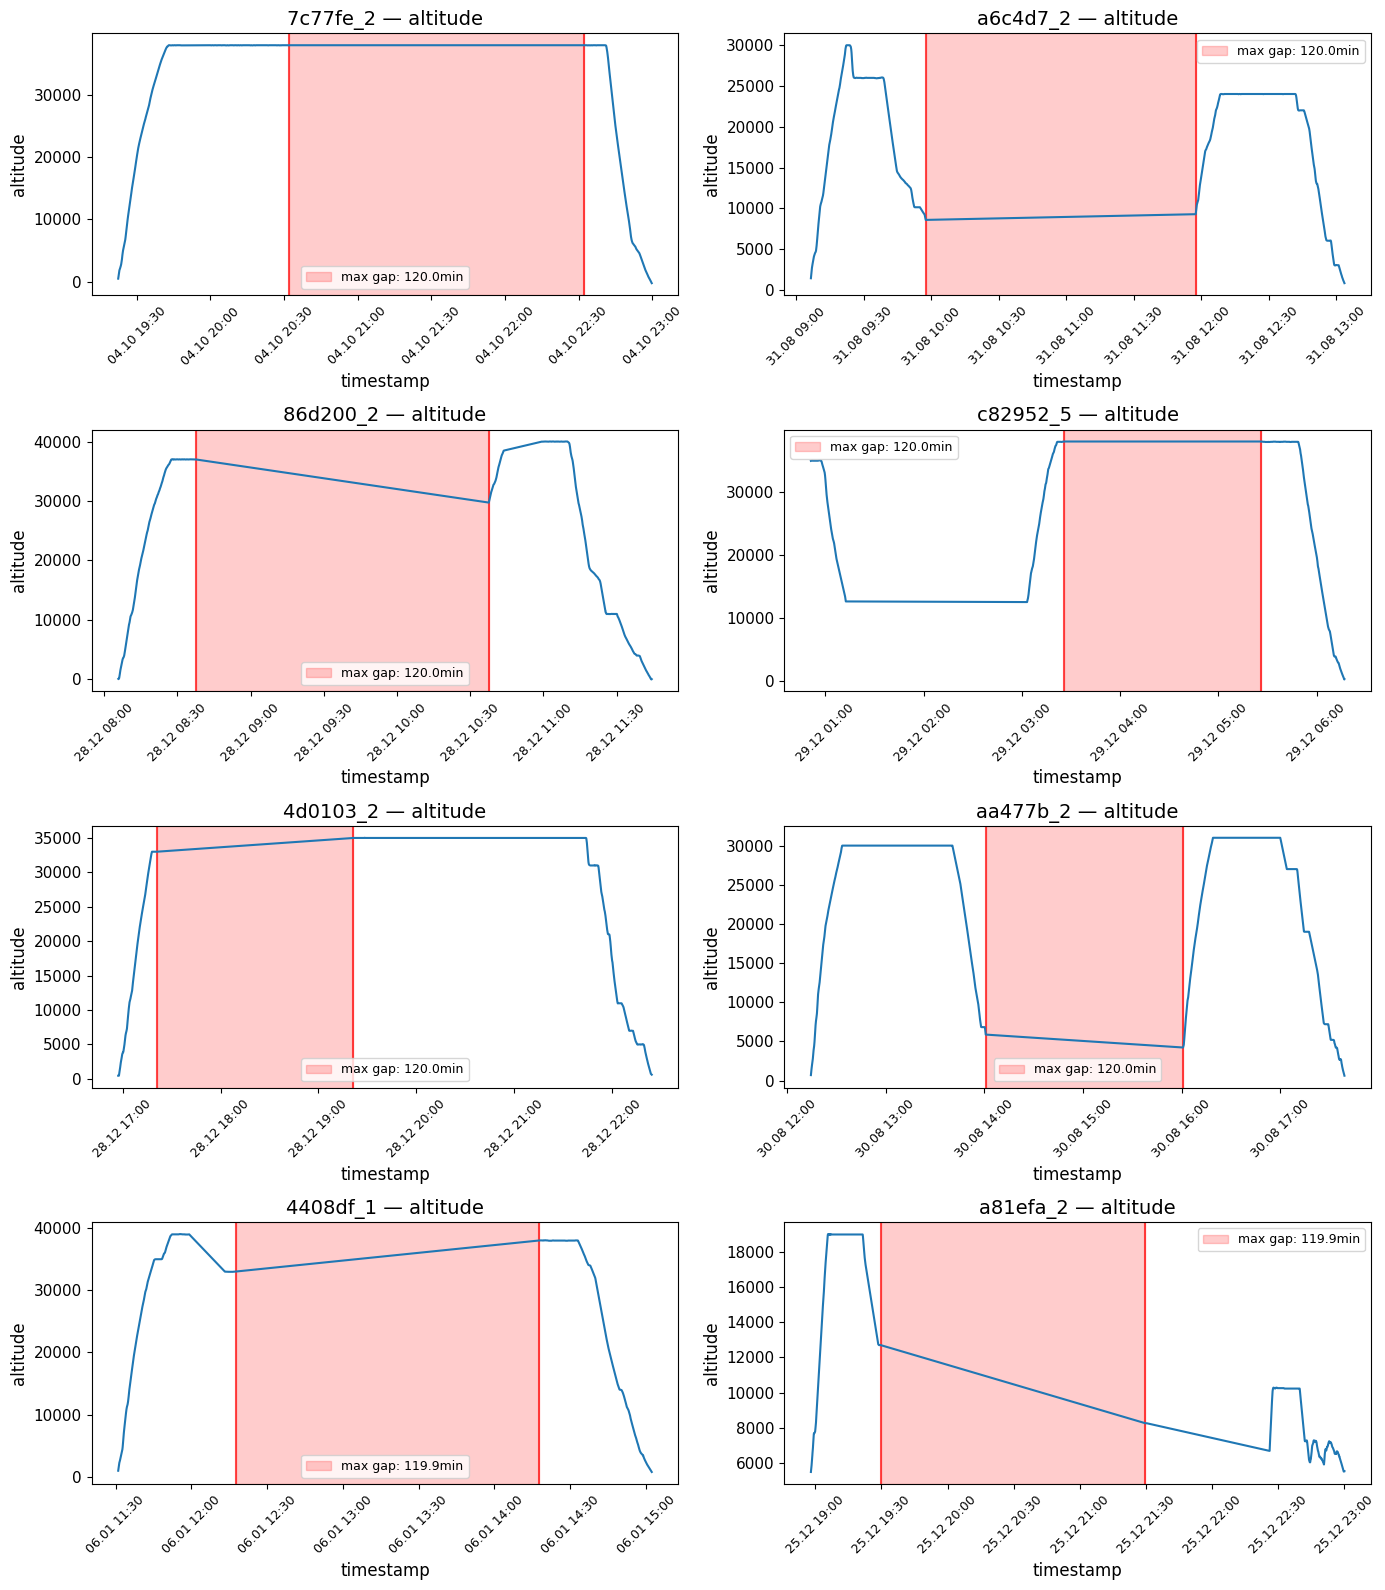

In [ ]:
from src.traces.plots_traces import *
plot_top_flights(df2, top_icaos, "altitude", "timestamp", n=8)

In [37]:
df = df2
df.head(3)

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
str,str,i64,"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,i64,str,str,str
"""00834c""","""E190""",0,2023-08-31 04:39:20.570 UTC,-26.976517,30.794574,38250.0,39900.0,422.1,234.4,384.0,1,"""adsb_icao""","""85bcf363fffffff""","""00834c_1"""
"""00834c""","""E190""",0,2023-08-31 04:39:38.750 UTC,-26.997179,30.7623,38425.0,40100.0,424.3,234.4,640.0,0,"""adsb_icao""","""85bcf363fffffff""","""00834c_1"""
"""00834c""","""E190""",0,2023-08-31 04:39:57.580 UTC,-27.018951,30.728345,38600.0,40275.0,424.3,234.4,576.0,0,"""adsb_icao""","""85bcf363fffffff""","""00834c_1"""


In [38]:
df.columns

['icao',
 'type',
 'dbFlags',
 'timestamp',
 'lat',
 'lon',
 'altitude',
 'altitude_geom',
 'ground_speed',
 'track_degrees',
 'vertical_rate',
 'flags',
 'source',
 'h3_5',
 'flight_id']

#### Cleansing NaN Values

In [39]:
df.null_count() / len(df) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.588109,0.0,0.0,0.0,0.0,6.460605,6.563587,0.709365,2.213335,6.571742,0.0,0.0,0.0,0.0


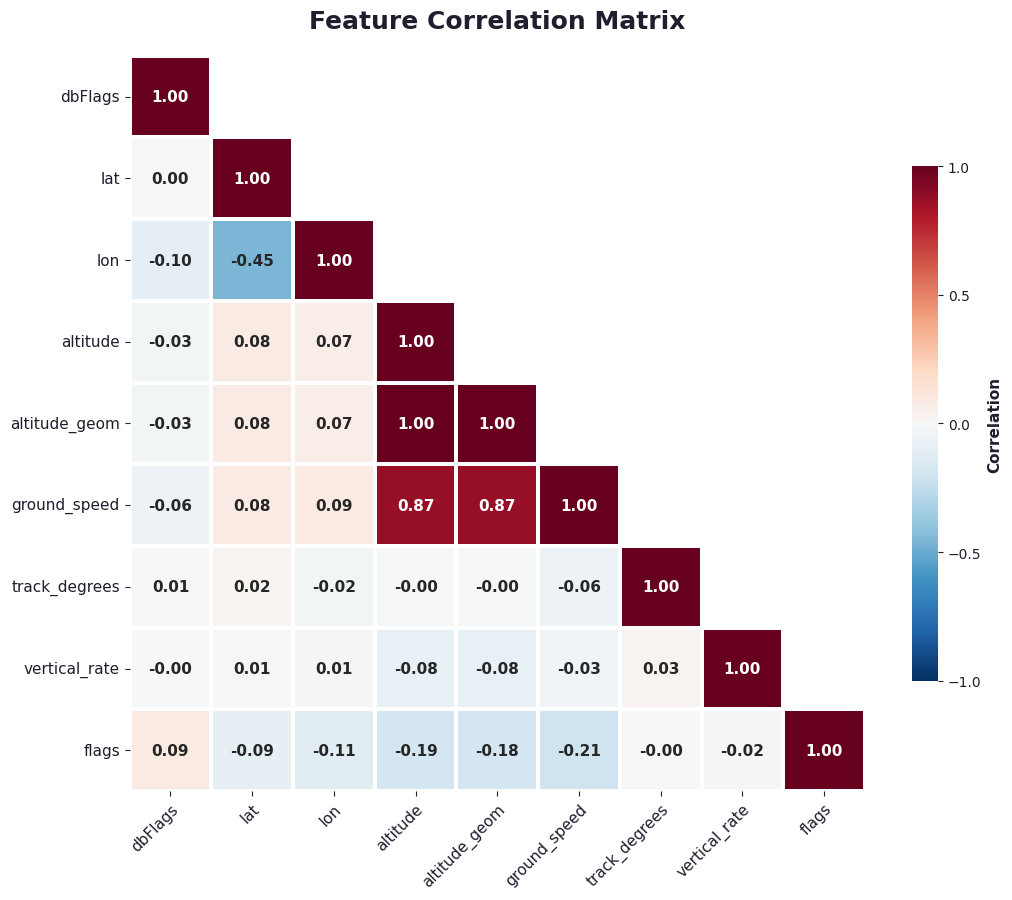

In [ ]:
from src.common.plots import *
plot_corr(df.to_pandas())

The matrix highlights two strong correlations: altitude ↔ altitude_geom (~1.00) and both ↔ ground_speed (~0.88), inspiring our imputation strategy, the two altitude columns serve as natural fallbacks for each other, and ground_speed is a reliable ground-state proxy.

In [41]:
df['flight_id'].n_unique()

93935

##### Ground Speed NaNs

We will start with the cleansing of ground speed, as this column will be used quite a bit when cleansing other columns

In [42]:
all_nan_gs = (
    df.group_by("icao")
    .agg(pl.col("ground_speed").is_null().all().alias("all_null"))
    .filter(pl.col("all_null"))
)

print(f"ICAOs with no ground_speed values at all: {all_nan_gs['icao'].to_list()}")
print(f"Count: {len(all_nan_gs)}")

ICAOs with no ground_speed values at all: ['0100a4', '300749', '31de32', '31de3c', '33ffd6', '3827fb', '3950cf', '398deb', '3d3d4f', '3fed34', '3fee2b', '3ff724', '3ff76a', '401292', '402de8', '440247', '45603e', '45603f', '456040', '456043', '45fe42', '45fe46', '45fe4b', '45fe50', '48515d', '485384', '48f44f', '4a7c24', '4a7c27', '4b2c73', '4cc088', '88805d', '888076', '896e7c', '896e7e', 'ae684b', 'e2003c', 'e4805d', 'e485af', 'e49431']
Count: 40


We will drop these ICAOs

In [43]:
df["ground_speed"].null_count() / len(df) * 100

0.7093647048658603

In [44]:
icaos_to_drop = all_nan_gs['icao'].to_list()
df = df.filter(~pl.col('icao').is_in(icaos_to_drop))

In [45]:
df['flight_id'].n_unique()

93879

In [46]:
df["ground_speed"].null_count() / len(df) * 100

0.6171092403673946

We still have 0.7% NaN values

In [47]:
nan_gs = df.filter(pl.col('ground_speed').is_null()).to_pandas()

In [49]:
print(nan_gs["icao"].value_counts().info())

<class 'pandas.Series'>
Index: 28922 entries, a16c31 to e94c86
Series name: count
Non-Null Count  Dtype
--------------  -----
28922 non-null  int64
dtypes: int64(1)
memory usage: 624.9 KB
None


We have ~40k ICAOs with missing NaNs

We will use linear interpolation and then forward and backward fill to cleanse these NaN values

In [50]:
df = df.with_columns(
    pl.col('ground_speed')
    .interpolate()
    .over('icao')
).with_columns(
    pl.col('ground_speed')
    .forward_fill()
    .over('icao')
)

In [51]:
df = df.with_columns(
    pl.col('ground_speed')
    .backward_fill()
    .over('icao')
)

In [52]:
df["ground_speed"].null_count() / len(df) * 100

0.0

We don't have any NaNs left

In [53]:
df.null_count() / len(df) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.588573,0.0,0.0,0.0,0.0,6.386483,6.477383,0.0,2.122477,6.489758,0.0,0.0,0.0,0.0


##### "altitude" and "altitude_geom" NaNs



We observe that `altitude` and `altitude_geom` contain ~6% NaN values. 
These are critical columns, so careful imputation is needed.

**Hypothesis:** Most NaN values correspond to ground operations (gate, taxi, 
holding). Transponders often do not broadcast barometric altitude while on the 
surface, so these NaNs reflect expected sensor behavior rather than data loss.

**Verification:** We compute the share of NaN-altitude rows with 
`ground_speed < 30 kt`. If the vast majority falls in this regime, the 
hypothesis holds and we impute these values with `0 ft`.

**Threshold rationale:** Industry practice (Boeing FCTM, common airline SOPs) 
caps taxi speed at ~25 kt on straight taxiways and ~30 kt on long taxi routes. 
Since takeoff rotation occurs around 130–160 kt, the 30 kt threshold leaves a 
wide margin and cannot be confused with active flight phases.

**Remaining NaNs** (in-flight, ground_speed ≥ 30 kt) are treated as data 
quality issues and handled in a second step.

> **Note:** ICAO guidelines recommend a maximum taxi speed of 25 kts on straight 
> taxiways (https://www.aviationfile.com/taxiing-by-the-numbers-maintaining-safe-speeds-on-the-apron/), while 30 kts is accepatable on long routes (https://aviationtricks.com/wp-content/uploads/2025/03/B737_FCTM-1.pdf)
> as our threshold to ensure we capture all ground operations without accidentally 
> including actual flight phases.



We define "altitude" and "altitude_geom" as fallback columns to each other, as these are very similar to each other, only differing in their measurement method and also ahd a correlation of 1. "Altitude" being barometrically measured by the aircraft itself, while "altitude_geom" refers to the geometric/GPS-derived altitude. When one is unavailable, the other serves as a reasonable substitute.

In [54]:
df["altitude", "altitude_geom"]

altitude,altitude_geom
f64,f64
38250.0,39900.0
38425.0,40100.0
38600.0,40275.0
38775.0,40450.0
38900.0,40600.0
…,…
19650.0,20675.0
20025.0,21050.0
21175.0,22200.0


In [55]:
in_air_nan = df.filter(pl.col("altitude").is_null())
print(f"altitude_geom available as fallback: {in_air_nan['altitude_geom'].is_not_null().sum()} / {len(in_air_nan)}")

altitude_geom available as fallback: 430070 / 3089776


In [56]:
in_air_nan2 = df.filter(pl.col("altitude_geom").is_null() )
print(f"altitude available as fallback: {in_air_nan2['altitude'].is_not_null().sum()} / {len(in_air_nan2)}")

altitude available as fallback: 474047 / 3133753


In [57]:
df = df.with_columns(
    pl.col("altitude").fill_null(pl.col("altitude_geom"))
)

In [58]:
df = df.with_columns(
    pl.col("altitude_geom").fill_null(pl.col("altitude"))
)

In [59]:
df.null_count() / len(df) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.588573,0.0,0.0,0.0,0.0,5.49754,5.49754,0.0,2.122477,6.489758,0.0,0.0,0.0,0.0


In [60]:
no_icaos = (
    df.group_by("icao")
    .agg(pl.col("altitude").is_null().all().alias("all_null"))
    .filter(pl.col("all_null"))
)

print(f"ICAOs with no altitude values at all: {no_icaos['icao'].to_list()}")
print(f"Count: {len(no_icaos)}")

ICAOs with no altitude values at all: ['009057', '0a8078', '0d0a8d', '152015', '398699', '3c4222', '3c4a8b', '4017dd', '4031c9', '4066de', '407fb5', '4247cd', '424846', '42584c', '425850', '448160', '448161', '449825', '44ce4f', '4676fc', '46779d', '484204', '4846e1', '48597d', '490031', '49130d', '49410d', '49e729', '49f015', '49f08a', '49f09d', '4ab590', '4ba95a', '4bb46d', '71c378', '78023e', '780aa3', '780c58', '781172', '7c333f', '7c492b', '7c6f84', '7cc599', '896120', 'a004a1', 'a0114f', 'a02cb5', 'a02da7', 'a038cc', 'a03c83', 'a0403a', 'a04f16', 'a07ca7', 'a07ccf', 'a0805e', 'a09a5f', 'a09cfe', 'a0a6cc', 'a0abfa', 'a0b6b7', 'a0b6e1', 'a0d331', 'a0de36', 'a0e1ed', 'a0e5a4', 'a0e9df', 'a0f322', 'a0f324', 'a0f6d9', 'a0fa90', 'a0fe47', 'a0feaf', 'a101fe', 'a10200', 'a11175', 'a1297d', 'a12d34', 'a134a2', 'a147d1', 'a14af6', 'a14bc9', 'a154b3', 'a1554e', 'a156c9', 'a1586a', 'a16273', 'a1699f', 'a1710d', 'a17ccd', 'a19377', 'a1b131', 'a1beaf', 'a1bf48', 'a1c61d', 'a1d4f9', 'a1d8b0', '

In [61]:
df['flight_id'].n_unique()

93879

In [62]:
icaos_to_drop = no_icaos['icao'].to_list()
df = df.filter(~pl.col('icao').is_in(icaos_to_drop))

In [63]:
df.null_count() / len(df) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.432055,0.0,0.0,0.0,0.0,5.219656,5.219656,0.0,1.859659,6.228492,0.0,0.0,0.0,0.0


In [64]:
df['flight_id'].n_unique()

93356

Let's further remove altitude NaNs

In [65]:
nan_alt = df.filter(pl.col("altitude").is_null())

In [66]:
thresholds = [10, 15, 30, 50, 75, 100]
for t in thresholds:
    n = (nan_alt['ground_speed'] >= t).sum()
    pct = n / len(nan_alt) * 100
    print(f"ground_speed >= {t} kts: {n} ({pct:.1f}%)")

ground_speed >= 10 kts: 1282658 (50.9%)
ground_speed >= 15 kts: 765710 (30.4%)
ground_speed >= 30 kts: 152099 (6.0%)
ground_speed >= 50 kts: 98902 (3.9%)
ground_speed >= 75 kts: 57526 (2.3%)
ground_speed >= 100 kts: 18861 (0.7%)


Around 94% have a ground speed below 30 kts, confirming our assumption that the vast majority are ground operations. The remaining ~8% (~190k rows) above 30 kts will be handled separately.


In [67]:
df = df.with_columns(
    pl.when(pl.col("altitude").is_null() & (pl.col("ground_speed") <= 30))
    .then(0)
    .otherwise(pl.col("altitude"))
    .alias("altitude")
)

In [68]:
df = df.with_columns(
    pl.when(pl.col("altitude_geom").is_null() & (pl.col("ground_speed") <= 30))
    .then(0)
    .otherwise(pl.col("altitude_geom"))
    .alias("altitude_geom")
)

In [69]:
df.null_count() / len(df) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.432055,0.0,0.0,0.0,0.0,0.315305,0.315305,0.0,1.859659,6.228492,0.0,0.0,0.0,0.0


In [70]:
df = df.with_columns(
    pl.col('altitude')
    .interpolate()
    .over('icao')
)

In [71]:
df = df.with_columns(
    pl.col('altitude_geom')
    .interpolate()
    .over('icao')
)

In [72]:
df.null_count() / len(df) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.432055,0.0,0.0,0.0,0.0,0.011487,0.011487,0.0,1.859659,6.228492,0.0,0.0,0.0,0.0


We still have 0.01% of NaN values. Let's use forward fill to remove those

In [73]:
df = df.with_columns(
    pl.col('altitude')
    .forward_fill()
    .over('icao')
).filter(pl.col('altitude').is_not_null())

In [74]:
df = df.with_columns(
    pl.col('altitude_geom')
    .forward_fill()
    .over('icao')
).filter(pl.col('altitude_geom').is_not_null())

In [75]:
df.null_count() / len(df) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.432065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.858581,6.226777,0.0,0.0,0.0,0.0


We succesfully removed those NaN values

For the remaining NaN values we will apply two different strategies:

- `track_degrees` (~2%): backward and forward fill, as gaps are negligible and values change slowly enough that the last known value is a reliable estimate.
- `vertical_rate` (~ 6%): linear interpolation, as a continuous physical 
  quantity (climb/sink rate), interpolating between known values is more 
  realistic than repeating the last known value.

##### Vertical Rate NaNs 

In [76]:
df['flight_id'].n_unique()

93352

In [77]:
all_nan_vert = (
    df.group_by("icao")
    .agg(pl.col("vertical_rate").is_null().all().alias("all_null"))
    .filter(pl.col("all_null"))
)

print(f"ICAOs with no vertical_rate values at all: {all_nan_vert['icao'].to_list()}")
print(f"Count: {len(all_nan_vert)}")

ICAOs with no vertical_rate values at all: ['0d09f0', '3006ff', '31dc54', '31dd29', '31df78', '31e048', '396700', '3985f1', '3d05ff', '3d0bcc', '3d0c97', '3d0fcc', '3d134e', '3d2341', '3d2543', '3d2f1d', '3d347e', '3d3731', '3d374e', '3d41aa', '3e60ae', '3e7a41', '3ecd4d', '3fcedc', '3fef4c', '3ff057', '3ff07e', '3ff2a0', '3ff2c6', '3ff2d0', '3ff54f', '3ff674', '3ff6f4', '3ff7e5', '3ff885', '3ff91e', '3ff925', '3ff9c4', '3ffa0b', '40139a', '401bad', '401bf7', '401efa', '4039b6', '404560', '4047bf', '404a8b', '404bf7', '4052ba', '4062bf', '406466', '406961', '406bcc', '407b35', '407c70', '407ed0', '407fd1', '44043e', '4407fa', '440aba', '440b54', '44a015', '473cc4', '48c1d7', '48ca66', '48fd20', '49c2c7', '4a9755', '4a9b59', '4aacd9', '4b0432', '4b3510', '7cbc35', '7cc408', '7cc427', '7cc44c', 'a01bd2', 'a069c6', 'a1f12d', 'a25ef0', 'a2baa2', 'a361bf', 'a4a5cb', 'a56a57', 'a5cbab', 'a651cd', 'a85ff5', 'a8f24d', 'a9bdaa', 'aa0415', 'aab1f6', 'ab232e', 'ab2734', 'ab2fa3', 'aca6cd', 'acaec

We will drop these ICAOs

In [78]:
icaos_to_drop = all_nan_vert['icao'].to_list()
df = df.filter(~pl.col('icao').is_in(icaos_to_drop))

In [79]:
df["vertical_rate"].null_count() / len(df) * 100

6.145611465624495

We still have 6% of NaN values

We will use linear interpolation and then forward and backward fill to cleanse these NaN values

In [80]:
df = df.with_columns(
    pl.col('vertical_rate')
    .interpolate()
    .over('icao')
).with_columns(
    pl.col('vertical_rate')
    .forward_fill()
    .over('icao')
)

In [81]:
df = df.with_columns(
    pl.col('vertical_rate')
    .backward_fill()
    .over('icao')
)

In [82]:
df["vertical_rate"].null_count() / len(df) * 100

0.0

In [83]:
df['flight_id'].n_unique()

93215

##### Track Degrees NaNs

In [84]:
all_nan_tg = (
    df.group_by("icao")
    .agg(pl.col("track_degrees").is_null().all().alias("all_null"))
    .filter(pl.col("all_null"))
)

print(f"ICAOs with no track_degrees values at all: {all_nan_tg['icao'].to_list()}")
print(f"Count: {len(all_nan_tg)}")

ICAOs with no track_degrees values at all: ['06a0ea', '06a12b', '0d0c6c', '3005bc', '3005fb', '300692', '30077e', '33febc', '342149', '342154', '342541', '342609', '3911cd', '392da4', '398c98', '3b77dd', '3cd950', '3d05cd', '3d065d', '3d0793', '3d0831', '3d0c1c', '3d0fdd', '3d1123', '3d1260', '3d13de', '3d15be', '3d1803', '3d192b', '3d196d', '3d1a31', '3d1a6c', '3d1ca2', '3d1f5a', '3d2293', '3d257b', '3d25c6', '3d2893', '3d31a2', '3d375a', '3d385a', '3d3922', '3d3a59', '3d416f', '3d43bc', '3d9b3e', '3da350', '3da357', '3daa4d', '3df03f', '3e1748', '3e1cc6', '3e2234', '3e5e2b', '3e625a', '3e6573', '3e675e', '3e7eba', '3ecf03', '3ed293', '3edca8', '3f28c7', '3f6dfa', '3f8f8b', '3f9af6', '3fee3f', '3ff72b', '400b6a', '400b76', '400c29', '400c2b', '400c8b', '400cb4', '400d78', '400da9', '400e86', '400ea2', '400ea3', '400eec', '400ffd', '4010c2', '40113f', '401148', '401252', '40133d', '401388', '401654', '40165e', '401759', '4018c2', '401a21', '401abf', '401c4f', '401ced', '401d15', '401d6

We will drop these ICAOs

In [85]:
icaos_to_drop = all_nan_tg['icao'].to_list()
df = df.filter(~pl.col('icao').is_in(icaos_to_drop))

In [86]:
df['flight_id'].n_unique()

92725

In [87]:
df["track_degrees"].null_count() / len(df) * 100

1.6405346598121133

We still have 1.7% NaN values

In [88]:
from src.traces.calc_bearing import *

In [89]:
temp = df.select(['icao', 'lat', 'lon']).to_pandas()
temp['track_degrees'] = temp.groupby('icao', group_keys=False).apply(calc_bearing)
df = df.with_columns(pl.Series('track_degrees', temp['track_degrees']))

In [90]:
df["track_degrees"].null_count() / len(df) * 100

0.07025803398455803

We are left with 0.07% missing values.

Imputation with ffill and bfil. Let's remove the remaining missing values

In [94]:
df = df.with_columns(
    pl.col('track_degrees')
    .forward_fill()
    .over('icao')
)

In [95]:
df = df.with_columns(
    pl.col('track_degrees')
    .backward_fill()
    .over('icao')
)

In [96]:
df.null_count() / len(df) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.430821,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### Type NaN Values

In [97]:
all_nan_tp = (
    df.group_by("icao")
    .agg(pl.col("type").is_null().all().alias("all_null"))
    .filter(pl.col("all_null"))
)

print(f"ICAOs with no type values at all: {all_nan_tp['icao'].to_list()}")
print(f"Count: {len(all_nan_tp)}")

ICAOs with no type values at all: ['38e05b', '3f616c', '44bd2c', '7cac57', '7caeb9', '7caed7', 'a0174e', 'a03849', 'a03959', 'a039ae', 'a03c79', 'a03eed', 'a0583d', 'a05d47', 'a06f70', 'a07ae8', 'a0b846', 'a0c9fb', 'a0d1c4', 'a0f978', 'a0fe2e', 'a0fe80', 'a0fe88', 'a0fea2', 'a0feb2', 'a0febf', 'a0fef7', 'a0fefb', 'a0fefe', 'a0ff05', 'a0ff0e', 'a100b7', 'a100cf', 'a100d0', 'a100f4', 'a10100', 'a10115', 'a10143', 'a1031b', 'a1036c', 'a14090', 'a14989', 'a15429', 'a165ea', 'a18b4b', 'a19a90', 'a1addc', 'a1b4bb', 'a1d395', 'a1daf9', 'a1fc31', 'a20a90', 'a243de', 'a2452f', 'a2454f', 'a24aa8', 'a2609d', 'a26454', 'a26f37', 'a26f79', 'a2adcb', 'a2c95a', 'a2d26c', 'a324b3', 'a3336a', 'a335eb', 'a34e00', 'a379d3', 'a37c1c', 'a38484', 'a38569', 'a398f4', 'a39ad4', 'a3a24b', 'a3a4ed', 'a3acac', 'a3b20b', 'a402ea', 'a406d8', 'a41ef0', 'a43a23', 'a4b059', 'a4c315', 'a4caa2', 'a4e954', 'a4ed4f', 'a4faf9', 'a50797', 'a51a76', 'a52709', 'a539c9', 'a55404', 'a5b536', 'a5e2b2', 'a64108', 'a650bb', 'a666

In [98]:
icaos_to_drop = all_nan_tp['icao'].to_list()
df = df.filter(~pl.col('icao').is_in(icaos_to_drop))

In [99]:
df = df.with_columns(
    pl.col('type')
    .backward_fill()
    .over('icao')
)

In [100]:
df = df.with_columns(
    pl.col('type')
    .forward_fill()
    .over('icao')
)

In [101]:
df.null_count() / len(df) * 100

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We successfully cleansed all missing values

In [102]:
df.head(5)

icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id
str,str,i64,"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,i64,str,str,str
"""00834c""","""E190""",0,2023-08-31 04:39:20.570 UTC,-26.976517,30.794574,38250.0,39900.0,422.1,234.297863,384.0,1,"""adsb_icao""","""85bcf363fffffff""","""00834c_1"""
"""00834c""","""E190""",0,2023-08-31 04:39:38.750 UTC,-26.997179,30.7623,38425.0,40100.0,424.3,234.250141,640.0,0,"""adsb_icao""","""85bcf363fffffff""","""00834c_1"""
"""00834c""","""E190""",0,2023-08-31 04:39:57.580 UTC,-27.018951,30.728345,38600.0,40275.0,424.3,234.298188,576.0,0,"""adsb_icao""","""85bcf363fffffff""","""00834c_1"""
"""00834c""","""E190""",0,2023-08-31 04:40:17.420 UTC,-27.041636,30.692896,38775.0,40450.0,426.5,234.315765,384.0,0,"""adsb_icao""","""85bcf377fffffff""","""00834c_1"""
"""00834c""","""E190""",0,2023-08-31 04:40:36.980 UTC,-27.064133,30.657711,38900.0,40600.0,428.7,234.306763,640.0,0,"""adsb_icao""","""85bcf377fffffff""","""00834c_1"""


In [103]:
df['flight_id'].n_unique()

92410

In [104]:
OUTPUT_CLEAN_PATH = PROCESSED_DIR / "normal_traces_cleansed.parquet"

In [105]:
df.write_parquet(OUTPUT_CLEAN_PATH)

In [106]:
print(pl.scan_parquet(NON_DUPLICATE_PATH).collect().shape)
print(pl.scan_parquet(OUTPUT_CLEAN_PATH).collect().shape)

(62381327, 14)
(47904016, 15)


After succesfully cleansing the dataset, we will move on with the data exploration of the original dataset. We still have aroudn 48 million rows of data

<!-- ##### Duplicate Check -->